# Week 1

**Date:** 2026-05-26

## Goals for this week

- [ ] Exploratory data analysis
- [ ] Set up environment (python, git repo, VS code? git and claude code integration?)
- [ ] Load the example dataset CSV and explore its structure
- [ ] Preliminary literature review: a few starter papers provided
- [ ] Others: set up next meeting time/frequency, brainstorm additional data?, etc.

## Setting up

Follow the instructions in README.md to install Python and create your virtual environment.
The datasets are already included in the `data/` folder of the repository. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data exploration

Here is some sample code for looking at the data:

In [2]:
# Load the example dataset
gs = pd.read_csv("data/example_data.csv")

# How many rows and columns?
print(f"Shape: {gs.shape}")
print(f"Columns: {list(gs.columns)}")
gs.head()

Shape: (1119, 22)
Columns: ['station_id', 'station_name', 'year', 'last_spring_frost_doy', 'first_fall_frost_doy', 'growing_season_length', 'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'ohc700_atlantic', 'ohc700_atlantic_se', 'ohc700_north_atlantic', 'ohc700_north_atlantic_se', 'ohc700_south_atlantic', 'ohc700_south_atlantic_se', 'ohc2000_north_atlantic', 'ohc700_pacific', 'ohc700_world', 'ohc700_natl_djf', 'ohc700_natl_amj']


,station_id,station_name,year,last_spring_frost_doy,first_fall_frost_doy,growing_season_length,oni_annual,nao_annual,nao_djf,pna_annual,...,ohc700_atlantic_se,ohc700_north_atlantic,ohc700_north_atlantic_se,ohc700_south_atlantic,ohc700_south_atlantic_se,ohc2000_north_atlantic,ohc700_pacific,ohc700_world,ohc700_natl_djf,ohc700_natl_amj
0,USW00014739,"Boston Logan, MA",1936,116,300,184,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00014739,"Boston Logan, MA",1937,93,290,197,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00014739,"Boston Logan, MA",1938,101,320,219,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00014739,"Boston Logan, MA",1939,107,291,184,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00014739,"Boston Logan, MA",1940,113,293,180,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Basic summary statistics
gs.describe()

,year,last_spring_frost_doy,first_fall_frost_doy,growing_season_length,oni_annual,nao_annual,nao_djf,pna_annual,amo_annual,ohc700_atlantic,ohc700_atlantic_se,ohc700_north_atlantic,ohc700_north_atlantic_se,ohc700_south_atlantic,ohc700_south_atlantic_se,ohc2000_north_atlantic,ohc700_pacific,ohc700_world,ohc700_natl_djf,ohc700_natl_amj
count,1119.000000,1119.000000,1119.000000,1119.000000,888.000000,888.000000,888.000000,888.000000,1095.000000,837.000000,837.000000,837.000000,837.000000,837.000000,837.000000,252.000000,837.000000,837.000000,837.000000,837.000000
mean,1974.943700,90.587131,312.312779,221.725648,0.023568,0.000713,0.179009,0.060425,0.001011,1.732171,0.338742,1.091541,0.185393,0.640530,0.286410,5.070048,1.524427,4.271038,1.050179,1.057894
std,34.200104,32.481001,23.199850,52.854145,0.616848,0.367346,0.811847,0.344938,0.189671,3.363720,0.179828,2.113809,0.093557,1.335976,0.141934,1.389082,2.954654,7.835661,2.070081,2.143977
min,1869.000000,1.000000,257.000000,110.000000,-1.225000,-1.152500,-1.590000,-0.712500,-0.447500,-2.544000,0.086000,-1.931000,0.039000,-1.318000,0.049000,3.241000,-2.983000,-5.728000,-1.671500,-2.338000
25%,1954.000000,81.000000,297.000000,188.000000,-0.475000,-0.243333,-0.350000,-0.171667,-0.127167,-1.068000,0.209000,-0.858000,0.111000,-0.410000,0.183000,3.807000,-0.635000,-2.189000,-0.896000,-0.763000
50%,1979.000000,98.000000,310.000000,213.000000,0.040833,-0.013333,0.390000,0.072500,0.021750,0.577000,0.311000,0.218000,0.160000,0.254000,0.246000,4.788000,0.516000,1.088000,0.433500,0.166000
75%,2002.000000,111.000000,324.000000,239.000000,0.446667,0.247500,0.750000,0.275000,0.163833,4.479000,0.429000,3.025000,0.226000,1.412000,0.385000,5.972000,3.791000,10.240000,2.971000,3.127000
max,2025.000000,163.000000,365.000000,364.000000,1.548333,1.083333,1.585000,0.807500,0.465083,9.232000,0.823000,5.355000,0.480000,3.877000,0.669000,7.462000,8.788000,22.845000,5.186000,5.634000


In [4]:
# Calculate number of unique stations, and date range
print(f"Number of stations: {gs['station_id'].nunique()}")
print(f"Year range: {gs['year'].min()} - {gs['year'].max()}")
print(f"\nStations:")
for sid, grp in gs.groupby("station_id"):
    name = grp["station_name"].iloc[0]
    print(f"  {name}: {grp['year'].min()}-{grp['year'].max()} ({len(grp)} years)")

Number of stations: 12
Year range: 1869 - 2025

Stations:
  Nashville, TN: 1954-2025 (72 years)
  Miami, FL: 1948-2025 (78 years)
  New Orleans, LA: 1970-2025 (56 years)
  Raleigh-Durham, NC: 1941-2025 (84 years)
  Pittsburgh, PA: 1930-2025 (96 years)
  Burlington, VT: 1939-2025 (87 years)
  Boston Logan, MA: 1936-2025 (90 years)
  Portland, ME: 1941-2025 (85 years)
  Chicago OHare, IL: 1939-2025 (87 years)
  Richmond, VA: 1940-2025 (86 years)
  Atlanta, GA: 1873-2025 (141 years)
  Central Park, NY: 1869-2025 (157 years)


## First plot: growing season length over time

Pick a station and plot its growing season length (GSL) across years.

Station with most records: Central Park, NY (USW00094728)


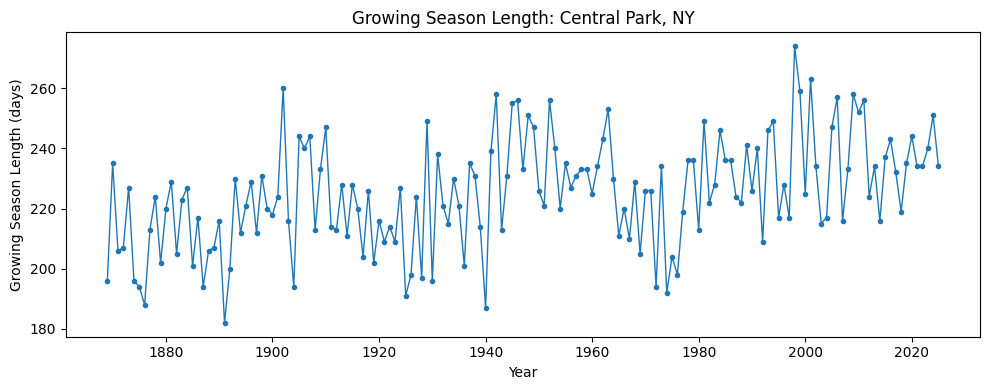

In [5]:
# Pick the station with the most data
top_station = gs.groupby("station_id").size().idxmax()
name = gs.loc[gs["station_id"] == top_station, "station_name"].iloc[0]
print(f"Station with most records: {name} ({top_station})")

one = gs[gs["station_id"] == top_station].sort_values("year")

plt.figure(figsize=(10, 4))
plt.plot(one["year"], one["growing_season_length"], marker=".", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Growing Season Length (days)")
plt.title(f"Growing Season Length: {name}")
plt.tight_layout()
plt.show()